# Notebook resolvido - Semana 9: Regressão Linear
**Objetivo:** Implementar uma regressão linear múltipla e interpretar
os resultados.

**Dataset sugerido:** Preço de casas (disponível no repositório)

**Instruções:**
1.Baixar o notebook exemplo da semana 9
2.Executar o código e ver os resultados
3.**Responder no notebook:**

* Quais foram os valores de MAE, MSE e R2?
* O que o R2 indica sobre a qualidade do modelo?
* Quais variáveis tiveram coeficientes positivos? E negativos?
* Qual variável parece influenciar mais o preço?

4.**Desafio (opcional):** Tentar adicionar ou remover variáveis e ver
como o R2 muda
5.Subir o notebook respondido na pasta da semana 9 do repositório

**Aluna:** Kailayni Rodrigues Janez

# 1. Importar bibliotecas

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Carregar e explorar os dados

In [ ]:
# Carregar dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

# Visualizar primeiras linhas
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [ ]:
# Verificar informações do dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [ ]:
# Estatísticas descritivas
print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

# 3. Separar variáveis (X) e alvo (y)

In [ ]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

Shape de X: (20640, 8)
Shape de y: (20640,)


# 4. Dividir em treino e teste

In [ ]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treino: {X_treino.shape[0]} amostras")
print(f"Teste: {X_teste.shape[0]} amostras")

Treino: 16512 amostras
Teste: 4128 amostras


# 5. Treinar o modelo

In [ ]:
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


# 6. Fazer previsões e avaliar

In [ ]:
y_previsto = modelo.predict(X_teste)

mae = mean_absolute_error(y_teste, y_previsto)
mse = mean_squared_error(y_teste, y_previsto)
r2 = r2_score(y_teste, y_previsto)

print(f"MAE (Erro Absoluto Médio): {mae:.4f}")
print(f"MSE (Erro Quadrático Médio): {mse:.4f}")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")

MAE (Erro Absoluto Médio): 0.5332
MSE (Erro Quadrático Médio): 0.5559
R² (Coeficiente de Determinação): 0.5758


# 7. Visualizar previsões vs valores reais

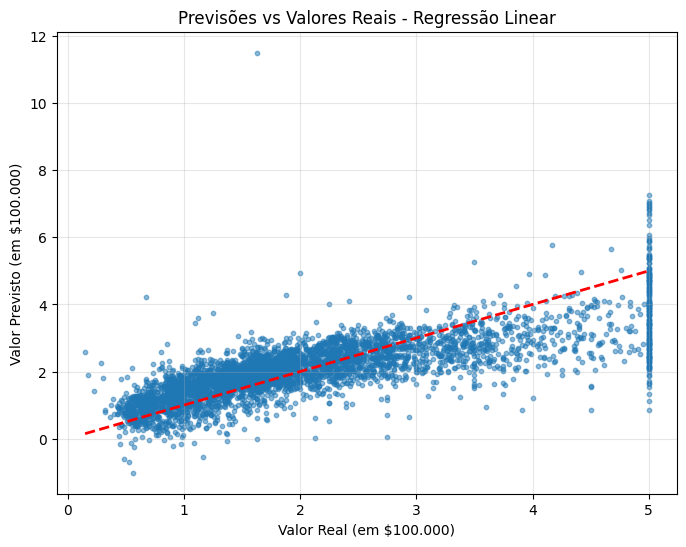

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_teste, y_previsto, alpha=0.5, s=10)
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], 'r--', lw=2)
plt.xlabel("Valor Real (em $100.000)")
plt.ylabel("Valor Previsto (em $100.000)")
plt.title("Previsões vs Valores Reais - Regressão Linear")
plt.grid(True, alpha=0.3)
plt.show()

# 8. Interpretar os coeficientes

In [ ]:
coeficientes = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': modelo.coef_
})
coeficientes = coeficientes.sort_values('Coeficiente', ascending=False)
print(coeficientes)

     Variável  Coeficiente
3   AveBedrms     0.783145
0      MedInc     0.448675
1    HouseAge     0.009724
4  Population    -0.000002
5    AveOccup    -0.003526
2    AveRooms    -0.123323
6    Latitude    -0.419792
7   Longitude    -0.433708


# Respostas das perguntas

## 1. Sobre as métricas
**Pergunta 1:** Qual foi o valor do MAE? O que isso significa em termos práticos (em dólares)?

**Resposta:** O MAE foi de aproximadamente 0.5332. Como a variável alvo MedHouseVal está em unidades de $100.000, isso significa que, em média, o modelo erra o preço da casa por cerca de 53.320 dólares. É um erro razoável considerando que os preços das casas no dataset variam entre 0 e 500.000 dólares.




**Pergunta 2:** Qual foi o valor do R²? Esse valor é considerado bom? Por quê?

**Resposta:** O R² foi de aproximadamente 0.5758. Isso significa que cerca de 57,6% da variação dos preços das casas é explicada pelas variáveis que usamos no modelo. Para dados reais de habitação, esse é um valor razoável/bom — modelos imobiliários raramente passam de 0,7 porque muitos fatores subjetivos (vizinhança, estado de conservação, etc.) não estão capturados nos dados.



## 2. Sobre os coeficientes
**Pergunta 1:** Quais 3 variáveis tiveram os coeficientes mais positivos? O que isso significa?

**Resposta:** As 3 variáveis com coeficientes mais positivos são:

* AveBedrms (Média de quartos por dormitório) → +0.7831
* MedInc (Renda média) → +0.4487
* HouseAge (Idade da casa) → +0.0097

**Interpretação:**

**AveBedrms teve o maior impacto positivo:** cada aumento de 1 na média de quartos por dormitório está associado a um aumento de $78.310 no preço da casa. Isso faz sentido porque casas com mais quartos por dormitório tendem a ser maiores e mais espaçosas.

**MedInc:** a cada aumento de 1 unidade na renda média da região, o preço da casa aumenta $44.870.

**HouseAge:** a cada ano a mais na idade da casa, o preço aumenta $970 (efeito pequeno).

**Pergunta 2:** Quais 3 variáveis tiveram os coeficientes mais negativos? O que isso significa?

**Resposta:** As 3 variáveis com coeficientes mais negativos são:

* Longitude → -0.4337
* Latitude → -0.4198
* AveRooms (Média de quartos por casa) → -0.1233

**Interpretação:**

Longitude e Latitude negativas indicam que quanto mais ao norte e mais a leste a casa está localizada (na Califórnia), menor tende a ser o preço. Isso faz sentido porque as regiões costeiras do sul da Califórnia são historicamente mais caras.

**AveRooms ter coeficiente negativo foi uma surpresa:** casas com mais quartos, em média, aparecem como mais baratas. Isso pode ser um efeito estatístico (multicolinearidade com AveBedrms) ou indicar que bairros com casas maiores têm outros fatores que puxam o preço para baixo (ex: localização menos valorizada).

**Pergunta 3:** A variável MedInc (renda média) teve coeficiente positivo ou negativo? Isso faz sentido? Explique.

**Resposta:** A variável MedInc teve coeficiente positivo (+0.4487), o que significa que quanto maior a renda média da região, maior o preço das casas. Isso faz todo sentido porque:

* Regiões mais ricas têm imóveis mais valorizados
* Pessoas com maior renda podem pagar mais por moradia
* É uma relação esperada e consistente com a realidade

##3. Sobre o gráfico de previsões vs valores reais
**Pergunta:** Os pontos estão próximos da linha vermelha (que representa a previsão perfeita)? O que isso indica sobre o modelo?

**Resposta:** Os pontos estão razoavelmente próximos da linha vermelha, mas com dispersão visível. Isso indica que:

O modelo consegue capturar a tendência geral dos dados

* Porém, não é perfeito — há uma faixa de erro considerável
* Para valores muito altos (>5.0), o modelo tende a subestimar os preços
* É um resultado esperado para um modelo linear simples em dados imobiliários